# 04 Reduction to the pole and pseudogravity

Ben Kay (ben@auscope.org.au)

A magnetic anomaly is skewed because the inducing field is inclined. For a
unit vector with inclination I (positive down) and declination D, and
wavenumber azimuth theta = atan2(kx, ky):

    Theta(I, D) = sin I + i cos I cos(theta - D)                Blakely 11.29

The TMI spectrum contains Theta_m Theta_f (magnetisation and field
directions). At the pole both are 1, so

    RTP           H = 1 / (Theta_m Theta_f)                      Blakely 12.31

turns the anomaly into what it would be over a vertically magnetised body
at the magnetic pole: symmetric, centred over the source. For induced
magnetisation Theta_m = Theta_f. Near the magnetic equator |Theta| gets
small in one direction and RTP amplifies noise; `amp_inclination` bounds
that. Not an issue in South Australia (I about -60 to -65).

Poisson's relation links the magnetic and gravity potentials of a body with
uniform magnetisation M and density rho, giving pseudogravity

    H = G rho / (Cm M) * 1 / (Theta_m Theta_f |k|)               Blakely 12.36

which is RTP followed by vertical integration. The output is the gravity the
body would produce if its magnetisation were replaced by density; only the
ratio rho / M sets the scale.

Field direction: use the IGRF value for the survey area and epoch. The
values in the setup cell are IGRF-13 for the Frome area at 2015.0
(computed with `ppigrf`).

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

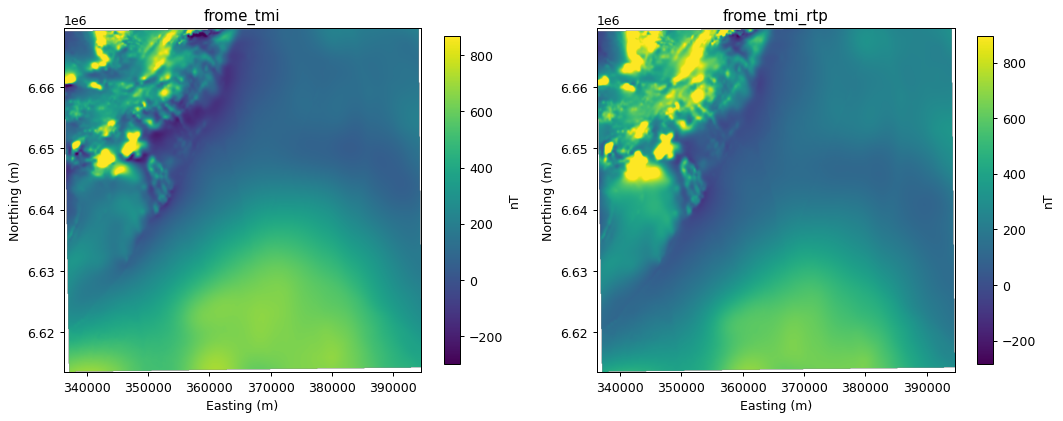

In [2]:
g = read_grid(f"{DATA}/frome_tmi.ers", bounds=(139.30, -30.60, 139.90, -30.10), epsg=28354, units="nT")
rtp = transforms.reduce_to_pole(g, INC, DEC)
fig, axes = display.compare([g, rtp], ncols=2, cmap="viridis", clip=("std", 2.5))

## What RTP does to a single body

Synthetic dipole at 1.5 km depth in the Frome field, then RTP. The pole
field computed directly is the target.

Text(0.5, 1.0, 'analytic pole field')

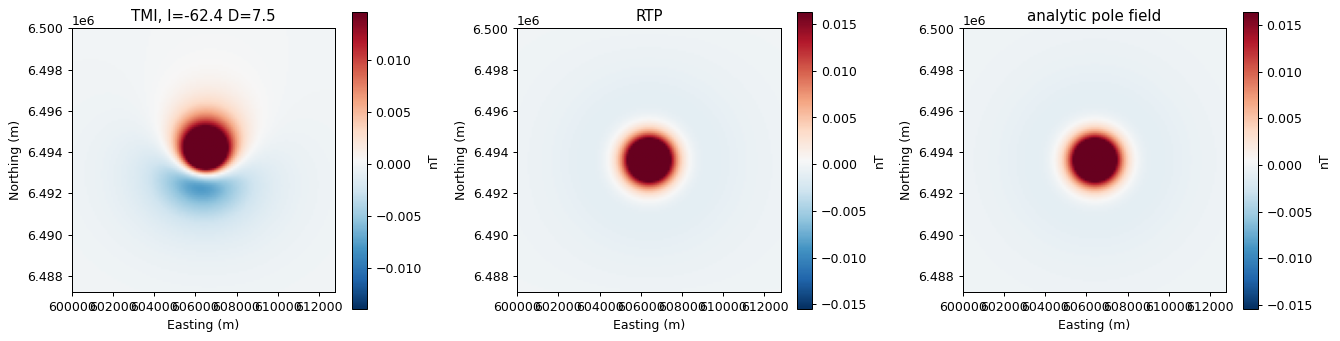

In [3]:
from potfield.synthetic import dipole_grid
tmi_syn = dipole_grid(128, 128, 100, z0=1500, moment=1e6, inc=INC, dec=DEC)
pole_syn = dipole_grid(128, 128, 100, z0=1500, moment=1e6, inc=90, dec=0)
rtp_syn = transforms.reduce_to_pole(tmi_syn, INC, DEC)
fig, axes = display.compare([tmi_syn, rtp_syn, pole_syn], ncols=3, cmap="RdBu_r", clip=("std", 3), figsize_per=(5, 4.5))
axes[0, 0].set_title("TMI, I=%.1f D=%.1f" % (INC, DEC)); axes[0, 1].set_title("RTP"); axes[0, 2].set_title("analytic pole field")

## Pseudogravity

With the defaults (rho 1000 kg/m^3, M 1 A/m) the numbers are only
meaningful relative to each other. Compare with the observed Bouguer
anomaly on the same geometry.

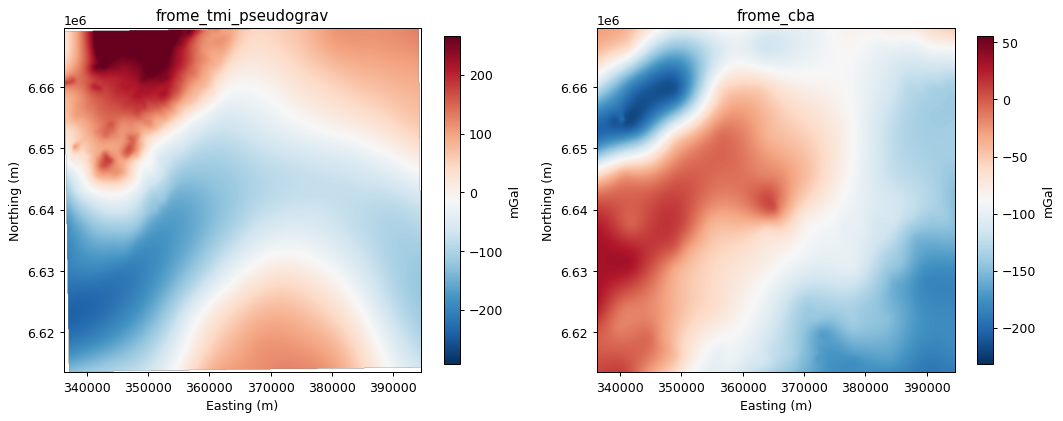

In [4]:
pg = transforms.pseudogravity(g, INC, DEC, density=1000, magnetisation=1.0)
cba = read_grid(f"{DATA}/frome_cba.ers", units="mGal").regrid(g)
fig, axes = display.compare([pg, cba], ncols=2, cmap="RdBu_r", clip=("std", 2.5))

In [5]:
import os
os.makedirs(OUT, exist_ok=True)
write_grid(rtp, f"{OUT}/frome_tmi_rtp.grd")
write_grid(pg, f"{OUT}/frome_pseudogravity.grd")

WindowsPath('../outputs/frome_pseudogravity.grd')